# PC Algorithm with Notre Dame's Prior DAG as Background Knowledge

This notebook performs causal discovery on the InOx thin-film dataset using the **PC (Peter–Clark) algorithm**, guided by the prior graph proposed by Notre Dame.  Because Notre Dame is **not fully certain** about that graph, we do **not** hard-code every edge as required. Instead, we use the prior to impose a **temporal/tier ordering** (the uncontroversial part) and then let the data speak about specific edges.

Variables used (13 total, selected for having the least missing data in the 51-sample master file):

- **6 controllable process parameters** – `O2 Flow`, `Substrate Temp`, `Pressure`, `Power`, `Anneal Temp`, `Anneal Cond` (anneal gas).
- **3 XPS features** (area under the photoelectron peaks) – `Area_In3d`, `Area_O1s`, `Area_Ta4f`. These proxy the Ta/In/O ratio that Notre Dame shows on its DAG.
- **3 XRD features** (peak heights) – `Height01`, `Height02`, `Height03`. These proxy the “XRD peak height” node.
- **1 response** – `Hall Mobility`.

Because the XPS peak position / XRD peak position / XRD FWHM nodes from Notre Dame’s DAG are **too sparse** in this dataset, the tests that involve those nodes are dropped from the prior and the remaining tier structure is kept.

## 1  PC algorithm — the full theory

The PC algorithm (Spirtes & Glymour, 1991) is a **constraint-based** causal discovery method: it learns a causal graph from data by running a *sequence of conditional independence tests* and combining the results with graph-theoretic rules.  Unlike regression, it does not assume any specific functional form; it only assumes the data satisfies the **causal Markov** and **faithfulness** conditions, plus **no latent confounders** (PC assumes causal sufficiency; if you suspect latent confounders use FCI).

### 1.1 Mathematical ingredients
- **Conditional independence (CI).** Two variables $X$ and $Y$ are conditionally independent given a set $S$ (written $X \perp\!\!\!\perp Y \mid S$) if $P(X,Y \mid S) = P(X \mid S)\,P(Y \mid S)$. For jointly Gaussian data this reduces to checking whether the **partial correlation** $\rho_{XY\cdot S}$ is zero — which is what Fisher’s $z$-test does.
- **d-separation.** A graphical criterion on a DAG that tells you which CIs the DAG implies. PC works because under faithfulness the CIs in the distribution match the d-separations in the true DAG.
- **CPDAG (completed partially directed acyclic graph).** Two DAGs are Markov-equivalent if they imply exactly the same CIs; they have the same skeleton and the same set of v-structures. The output of PC is the **CPDAG** of the equivalence class: some edges are directed, others are left undirected because the data alone cannot choose a direction.

### 1.2 The four phases

**Phase 1 — Start fully connected.**
Begin with a complete undirected graph on all $p$ variables. Every pair has an edge; we will try to prove it does not belong.

**Phase 2 — Skeleton discovery (edge removal).**
For increasing conditioning-set size $\ell = 0, 1, 2, \dots$:
 For every adjacent pair $(X, Y)$, look at subsets $S \subseteq \mathrm{Adj}(X)\setminus\{Y\}$ of size $\ell$.
 Test $X \perp\!\!\!\perp Y \mid S$ at significance level $\alpha$.
 If a separating set $S$ is found, **delete the edge $X\!-\!Y$** and **record $S$** in $\mathrm{sepset}(X,Y)$.
Stop when no node has enough neighbours to form a bigger conditioning set.

> *Why this works.* If $X$ and $Y$ are not directly causally connected, the true DAG d-separates them given some subset of their neighbours; under faithfulness the data will show the CI and the edge is removed. If they are directly connected, *no* conditioning set can separate them — the edge survives.

**Phase 3 — Orient v-structures (colliders).**
For every unshielded triple $X \!-\! Z \!-\! Y$ (i.e. $X$ and $Y$ not adjacent):
 If **$Z$ is NOT in $\mathrm{sepset}(X,Y)$**, orient it as the v-structure $X \to Z \leftarrow Y$.
These are the only orientations that can be made from CI information alone.

**Phase 4 — Meek orientation rules.**
Propagate the directions without creating new v-structures or cycles:
- *R1.* If $A \to B - C$ and $A, C$ are not adjacent, orient $B \to C$.
- *R2.* If $A \to B \to C$ and $A - C$, orient $A \to C$.
- *R3.* If $A - B$, $A - C$, $A - D$, $C \to B$, $D \to B$ and $C, D$ are not adjacent, orient $A \to B$.
- *R4.* (A more complex rule handling mixed triples.)

What remains undirected after Meek is genuinely **unidentifiable** from data alone — that is where background knowledge matters.

### 1.3 How `causal-learn` implements this
- `indep_test='fisherz'` — partial correlation test, appropriate for continuous, roughly Gaussian data.
- `alpha` — larger $\alpha$ keeps more edges (more Type I errors); smaller $\alpha$ removes more edges (more Type II errors). With only ~45 samples and 13 variables, $\alpha \in [0.05, 0.10]$ is a reasonable range.
- `uc_rule=0` — use the sepset rule for colliders (Phase 3).
- `stable=True` — deterministic skeleton (ordering of tests does not matter).

### 1.4 Adding background knowledge
`causal-learn` lets us inject:
- **Required** edges — forced to appear, direction fixed.
- **Forbidden** edges — removed if PC tries to orient them this way.
- **Tiers** — ordered groups of nodes; edges from a later tier to an earlier tier are forbidden everywhere.

Background knowledge is used in **Phase 2** (forbidden edges are deleted), **Phase 3** (required edges override collider rule) and **Phase 4** (Meek respects the constraints).  Tier constraints are the **safest** way to encode a “causal order” without pretending we are sure about specific edges — which is exactly Notre Dame’s situation.

## 2  Notre Dame’s proposed DAG (prior)

From the diagram you shared, the proposed causal structure is (free-text transcription):

- `O2 flow` → `Ta/In/O ratio` (XPS areas), `Hall mobility`
- `T_sub` → `XPS peak position`, `XRD peak position`, `XRD FWHM`, `XRD peak height`, `Hall mobility`
- `Pressure` → `XRD peak position`, `Hall mobility`
- `Power` → `XPS peak position`, `XRD FWHM`
- `T_anneal` → `XRD peak height`, `XRD peak position`
- `Anneal gas` → `XRD peak height`, `Hall mobility`
- `Ta/In/O ratio` → `Hall mobility`
- `XPS peak position`, `XRD peak position`, `XRD FWHM`, `XRD peak height` → `Hall mobility`

The graph has a clear **3-tier structure**:

1. **Tier 0** – controllable process parameters (roots).
2. **Tier 1** – structural/chemical characterization (XPS & XRD features).
3. **Tier 2** – Hall mobility (terminal effect).

This tier ordering is **physics-motivated** and therefore trustworthy even if the specific edges between tiers are unsure:
- You *choose* the process knobs, so the XPS/XRD and the mobility cannot cause them.
- Mobility is the downstream electrical response; it cannot alter the film’s structure retroactively.

We will encode the tiers as the **main** background knowledge, plus a handful of **required** edges for the associations Notre Dame is most confident about (`O2 flow → XPS areas`, `Anneal gas → XRD heights`).

In [1]:
# --- preamble ---
import os
if os.path.basename(os.getcwd()) != 'repository_dmref':
    os.chdir('..')
print('cwd =', os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

cwd = /data/zhq7531/IDEAL/DMREF/repository_dmref


## 3  Data preparation

Load the 51-sample master file, select the 13 chosen columns, and drop rows with any missing values. XPS areas have 1 missing row, XRD heights have 0 missing rows, Hall mobility has 5 missing rows, so after `dropna` we expect ~45 usable samples.

In [2]:
master_df = pd.read_pickle('output/master_df.pkl')

# Rename for terser labels
master_df = master_df.rename(columns={
    'Substrate Temp (°C)': 'Sub Temp',
    'Anneal Temp (°C)': 'Ann Temp',
    'Hall Mobility (cm^2/V·s)': 'Hall Mob',
    'Anneal Condition Num': 'Ann Gas',
    'Power (W)': 'Power',
    'O2 Flow (sccm)': 'O2 Flow',
    'Pressure (mTorr)': 'Pressure',
})

PROCESS = ['O2 Flow', 'Sub Temp', 'Pressure', 'Power', 'Ann Temp', 'Ann Gas']
XPS     = ['Area_In3d', 'Area_O1s', 'Area_Ta4f']
XRD     = ['Height01', 'Height02', 'Height03']
RESP    = ['Hall Mob']
LABELS  = PROCESS + XPS + XRD + RESP

df = master_df[LABELS].apply(pd.to_numeric, errors='coerce').dropna()
print(f'Usable rows after dropna: {len(df)} / {len(master_df)}')
print('Columns:', LABELS)
df.head()

Usable rows after dropna: 46 / 51
Columns: ['O2 Flow', 'Sub Temp', 'Pressure', 'Power', 'Ann Temp', 'Ann Gas', 'Area_In3d', 'Area_O1s', 'Area_Ta4f', 'Height01', 'Height02', 'Height03', 'Hall Mob']


,O2 Flow,Sub Temp,Pressure,Power,Ann Temp,Ann Gas,Area_In3d,Area_O1s,Area_Ta4f,Height01,Height02,Height03,Hall Mob
0,0.3,25,2,10,150,1,26247.0,3497.0,0.0,328,1253,1076,12.20
1,0.3,25,2,10,150,1,28819.0,3669.0,0.0,689,832,0,3.02
2,0.3,25,2,10,150,1,28042.0,3617.0,0.0,1261,630,0,49.50
3,0.3,25,4,10,400,2,27761.0,3286.0,0.0,853,519,0,9.03
5,0.3,25,4,10,400,2,29500.0,3561.0,0.0,1312,486,0,17.20


## 4  Encoding the background knowledge

We build a `BackgroundKnowledge` object that:

1. Assigns each variable to a tier (0 / 1 / 2) matching the physics picture.
2. Forbids within-tier edges in tier 0 (process parameters are varied independently by the DOE and therefore should not cause each other).
3. Adds a small number of **required** edges that encode Notre Dame’s most confident claims about inter-tier links.

Everything else is left to the data.

In [3]:
# Pre-build GraphNode objects with the same names as the PC nodes
nodes = {name: GraphNode(name) for name in LABELS}

bk = BackgroundKnowledge()

# --- Tier 0 : controllable process parameters ----------------------------
for n in PROCESS:
    bk.add_node_to_tier(nodes[n], 0)
bk.forbid_within_tier(0)   # process params do not cause each other

# --- Tier 1 : structural / chemical characterisation ---------------------
for n in XPS + XRD:
    bk.add_node_to_tier(nodes[n], 1)
# We leave tier 1 internally unrestricted (XPS and XRD may share causes)

# --- Tier 2 : electrical response ----------------------------------------
bk.add_node_to_tier(nodes['Hall Mob'], 2)

# --- Required edges that Notre Dame is most confident about --------------
# O2 flow influences the Ta / In / O elemental areas (XPS)
for x in XPS:
    bk.add_required_by_node(nodes['O2 Flow'], nodes[x])
# Anneal gas and anneal temperature influence XRD peak heights
for h in XRD:
    bk.add_required_by_node(nodes['Ann Gas'],  nodes[h])
    bk.add_required_by_node(nodes['Ann Temp'], nodes[h])

print('Tier assignment:')
print('  Tier 0 (process):', PROCESS)
print('  Tier 1 (XPS+XRD):', XPS + XRD)
print('  Tier 2 (response):', RESP)
print(f'\nForbidden edges (from tiering): every back-in-time edge, plus within-tier-0 edges.')
print(f'Required edges: {len(bk.required_rules_specs)}  (O2 Flow→XPS areas, Ann Gas/Ann Temp→XRD heights)')

Tier assignment:
  Tier 0 (process): ['O2 Flow', 'Sub Temp', 'Pressure', 'Power', 'Ann Temp', 'Ann Gas']
  Tier 1 (XPS+XRD): ['Area_In3d', 'Area_O1s', 'Area_Ta4f', 'Height01', 'Height02', 'Height03']
  Tier 2 (response): ['Hall Mob']

Forbidden edges (from tiering): every back-in-time edge, plus within-tier-0 edges.
Required edges: 9  (O2 Flow→XPS areas, Ann Gas/Ann Temp→XRD heights)


## 5  Helpers — graph conversion and plotting

**How to read the plots below:**

- A **solid arrow  A → B**  means PC (together with any background knowledge) was able to orient the edge: the data plus the prior imply *A causes B*.
- A **dashed, arrow-less line  A — B**  means PC found that the two variables are *directly dependent* (the edge survived skeleton pruning) but it could **not determine the direction** from the conditional-independence tests alone. Multiple Markov-equivalent DAGs fit the data equally well for that edge. This is a fundamental limitation of constraint-based causal discovery, not a bug — it is why the output is called a **CPDAG** instead of a DAG.
- A **blue arrow** marks an edge that came from Notre Dame's prior (we asserted it via `add_required_by_node`). Black arrows came from the data.

Two common reasons you might see dashed edges:
1. The edge lies inside a tier where we *allowed* within-tier links (tier 1, XPS/XRD). PC has no prior constraint to tie-break direction.
2. PC did not detect a v-structure that would force the direction, and Meek's propagation rules did not fire.

In [4]:
def clearn_to_nx(graph_obj, labels):
    """Convert a causal-learn GeneralGraph to a NetworkX DiGraph.

    Encoding in causal-learn:
       adj[i,j] = -1, adj[j,i] = +1  => i -> j (directed)
       adj[i,j] = -1, adj[j,i] = -1  => i -- j (undirected, direction unknown)
       adj[i,j] = +1, adj[j,i] = +1  => i <-> j (bidirected, e.g. latent confounder)
    """
    G = nx.DiGraph()
    G.add_nodes_from(labels)
    adj = graph_obj.graph
    n = len(labels)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            if adj[i, j] == -1 and adj[j, i] == 1:
                G.add_edge(labels[i], labels[j])
            elif adj[i, j] == -1 and adj[j, i] == -1 and i < j:
                G.add_edge(labels[i], labels[j], undirected=True)
    return G


# Fixed positions: tier 0 at top, tier 1 in middle, Hall Mob at bottom
def tiered_layout():
    pos = {}
    for i, n in enumerate(PROCESS):
        pos[n] = (i * 1.6 - (len(PROCESS) - 1) * 0.8, 2.0)
    for i, n in enumerate(XPS + XRD):
        pos[n] = (i * 1.6 - (len(XPS + XRD) - 1) * 0.8, 1.0)
    pos['Hall Mob'] = (0.0, 0.0)
    return pos

def node_color(n):
    if n in PROCESS: return '#4ECDC4'
    if n in XPS:     return '#FFE66D'
    if n in XRD:     return '#FFB347'
    return '#FF6B6B'


NODE_SIZE = 2200

def plot_graph(G, title, ax=None, highlight_required=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(13, 7))
    pos = tiered_layout()
    directed   = [(u, v) for u, v, d in G.edges(data=True) if not d.get('undirected')]
    undirected = [(u, v) for u, v, d in G.edges(data=True) if d.get('undirected')]

    required = highlight_required or set()
    req_edges  = [(u, v) for (u, v) in directed if (u, v) in required]
    disc_edges = [(u, v) for (u, v) in directed if (u, v) not in required]

    # Draw nodes FIRST so edges/arrowheads render on top
    colors = [node_color(n) for n in G.nodes]
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=NODE_SIZE,
                           edgecolors='#333', linewidths=1.3)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_weight='bold')

    # CRITICAL: pass node_size so networkx places arrowheads at the node boundary
    # (without this, arrows end *inside* the node circle and look like no arrow).
    nx.draw_networkx_edges(G, pos, edgelist=disc_edges, ax=ax, arrows=True,
                           arrowstyle='-|>', arrowsize=25, edge_color='#222',
                           width=1.6, node_size=NODE_SIZE, min_target_margin=16)
    if req_edges:
        nx.draw_networkx_edges(G, pos, edgelist=req_edges, ax=ax, arrows=True,
                               arrowstyle='-|>', arrowsize=25, edge_color='#1f77b4',
                               width=2.4, node_size=NODE_SIZE, min_target_margin=16)
    if undirected:
        nx.draw_networkx_edges(G, pos, edgelist=undirected, ax=ax, arrows=False,
                               style='dashed', edge_color='#888', width=1.3,
                               node_size=NODE_SIZE)

    ax.set_title(title, fontsize=12)
    ax.axis('off')

    legend = [mpatches.Patch(color='#4ECDC4', label='Process (tier 0)'),
              mpatches.Patch(color='#FFE66D', label='XPS areas (tier 1)'),
              mpatches.Patch(color='#FFB347', label='XRD heights (tier 1)'),
              mpatches.Patch(color='#FF6B6B', label='Hall mobility (tier 2)'),
              mpatches.Patch(color='#222',    label='directed  A → B  (data)'),
              mpatches.Patch(color='#888',    label='undirected  A — B  (CPDAG tie)')]
    if highlight_required is not None:
        legend.append(mpatches.Patch(color='#1f77b4', label='required edge (prior)'))
    ax.legend(handles=legend, loc='upper left', bbox_to_anchor=(1.02, 1.0), fontsize=8)
    return ax

## 6  PC without background knowledge (baseline)

We first run PC with no prior at all. This reproduces exactly what the data says — the edges we see here are what the CI tests alone reveal.

  0%|          | 0/13 [00:00<?, ?it/s]

PC (no prior) — directed edges: 7, undirected (CPDAG): 3


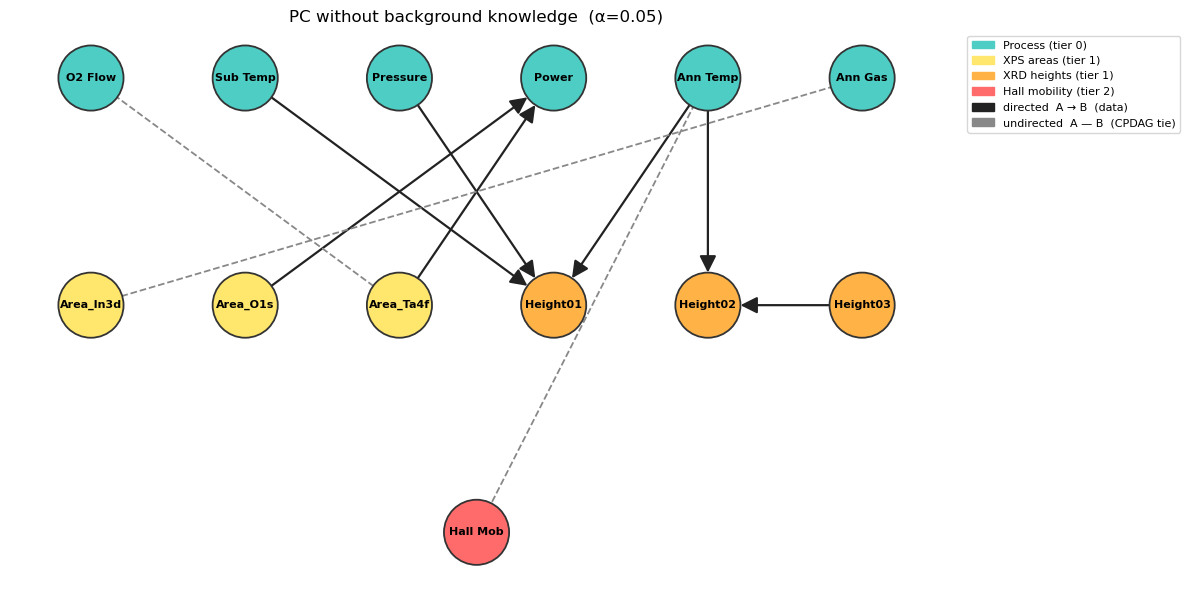

In [5]:
ALPHA = 0.05

pc_vanilla = pc(df.values, alpha=ALPHA, indep_test='fisherz', node_names=LABELS)
G_vanilla = clearn_to_nx(pc_vanilla.G, LABELS)

n_dir  = sum(1 for _, _, d in G_vanilla.edges(data=True) if not d.get('undirected'))
n_undir = sum(1 for _, _, d in G_vanilla.edges(data=True) if d.get('undirected'))
print(f'PC (no prior) — directed edges: {n_dir}, undirected (CPDAG): {n_undir}')

fig, ax = plt.subplots(figsize=(12, 6))
plot_graph(G_vanilla, f'PC without background knowledge  (α={ALPHA})', ax=ax)
plt.tight_layout(); plt.show()

## 7  PC *with* Notre Dame’s prior as background knowledge

Now we pass the `BackgroundKnowledge` object we built in section 4. The algorithm:
1. Deletes edges that violate tier forbidden-ness during skeleton discovery.
2. Orients required edges before the collider phase.
3. Uses tier constraints as tie-breakers in Meek orientation.

Required edges are drawn in **blue** so you can see which edges came from the prior versus which came from the data.

  0%|          | 0/13 [00:00<?, ?it/s]

PC (with prior) — directed edges: 10, undirected (CPDAG): 0


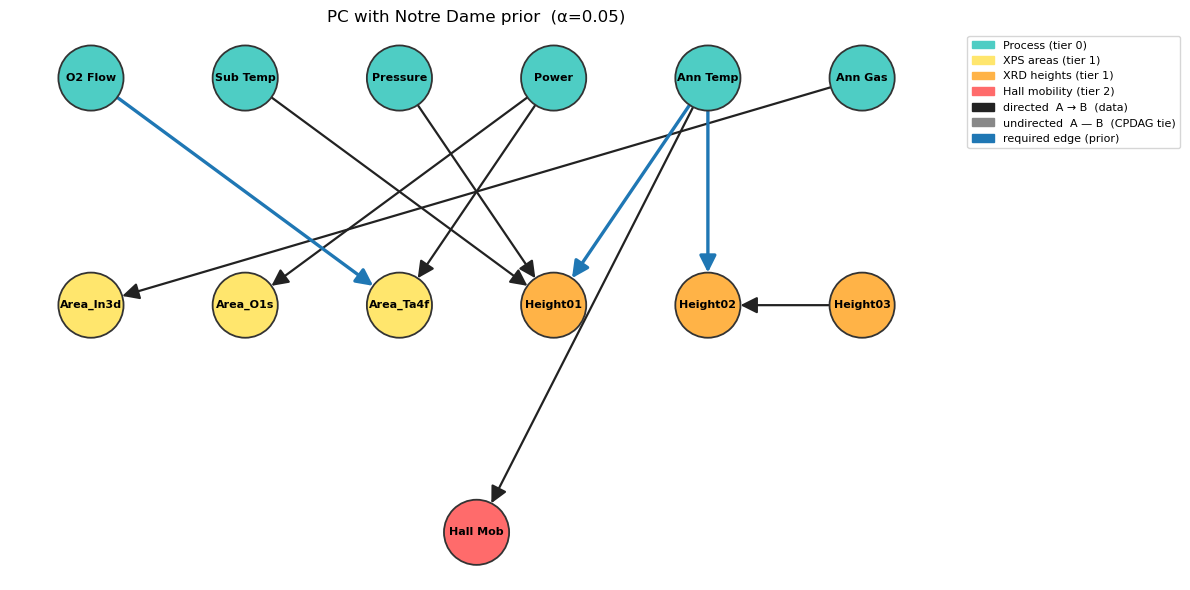

In [6]:
pc_prior = pc(df.values, alpha=ALPHA, indep_test='fisherz',
              node_names=LABELS, background_knowledge=bk)
G_prior = clearn_to_nx(pc_prior.G, LABELS)

# Rebuild the required-edge set as a plain (src, dst) set
REQUIRED_EDGES = {(u.get_name(), v.get_name()) for (u, v) in bk.required_rules_specs}

n_dir  = sum(1 for _, _, d in G_prior.edges(data=True) if not d.get('undirected'))
n_undir = sum(1 for _, _, d in G_prior.edges(data=True) if d.get('undirected'))
print(f'PC (with prior) — directed edges: {n_dir}, undirected (CPDAG): {n_undir}')

fig, ax = plt.subplots(figsize=(12, 6))
plot_graph(G_prior, f'PC with Notre Dame prior  (α={ALPHA})', ax=ax,
           highlight_required=REQUIRED_EDGES)
plt.tight_layout(); plt.show()

## 8  Side-by-side comparison

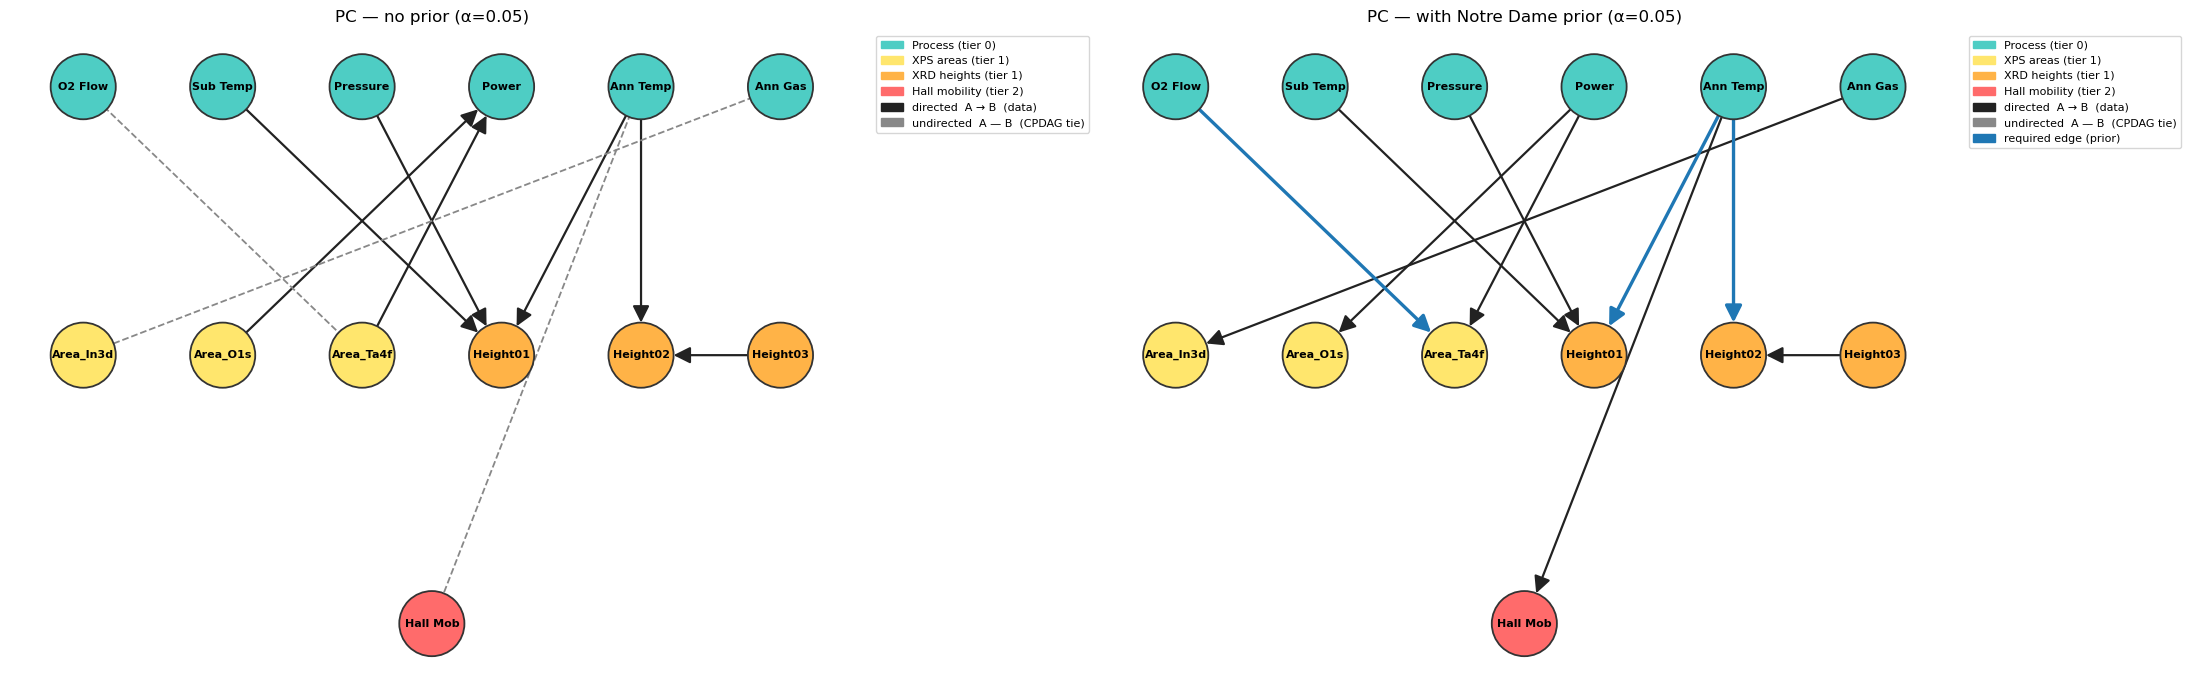

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(22, 7))
plot_graph(G_vanilla, f'PC — no prior (α={ALPHA})', ax=axes[0])
plot_graph(G_prior,   f'PC — with Notre Dame prior (α={ALPHA})',
           ax=axes[1], highlight_required=REQUIRED_EDGES)
plt.tight_layout(); plt.show()

## 9  Agreement with Notre Dame’s proposed edges

We translate Notre Dame’s DAG into the variables we actually have (dropping the edges that reference XPS-peak-position / XRD-peak-position / XRD-FWHM which are too sparse) and check which are recovered by PC.

In [8]:
# Notre Dame DAG edges projected onto the chosen variable set
ND_EDGES = set()
# O2 flow → XPS areas and → Hall mobility
for x in XPS:
    ND_EDGES.add(('O2 Flow', x))
ND_EDGES.add(('O2 Flow', 'Hall Mob'))
# T_sub → XPS, XRD and Hall mobility
for x in XPS + XRD:
    ND_EDGES.add(('Sub Temp', x))
ND_EDGES.add(('Sub Temp', 'Hall Mob'))
# Pressure → Hall mobility  (edge to XRD peak position is out of scope)
ND_EDGES.add(('Pressure', 'Hall Mob'))
# T_anneal and Anneal gas → XRD heights
for h in XRD:
    ND_EDGES.add(('Ann Temp', h))
    ND_EDGES.add(('Ann Gas',  h))
# Anneal gas → Hall mobility
ND_EDGES.add(('Ann Gas', 'Hall Mob'))
# XPS areas, XRD heights → Hall mobility
for v in XPS + XRD:
    ND_EDGES.add((v, 'Hall Mob'))

def edge_set(G):
    return {(u, v) for u, v, d in G.edges(data=True) if not d.get('undirected')}

E_vanilla = edge_set(G_vanilla)
E_prior   = edge_set(G_prior)

rows = []
for e in sorted(ND_EDGES):
    rows.append({
        'Edge': f'{e[0]} → {e[1]}',
        'PC (no prior)':  '✓' if e in E_vanilla else '✗',
        'PC (with prior)': '✓' if e in E_prior   else '✗',
        'Required in prior': '*' if e in REQUIRED_EDGES else '',
    })
agree_df = pd.DataFrame(rows)

print(f'Notre Dame edges (after projection): {len(ND_EDGES)}')
print(f'Recovered by PC without prior:      {len(ND_EDGES & E_vanilla)}')
print(f'Recovered by PC with prior:         {len(ND_EDGES & E_prior)}')
print(f'Novel edges only discovered by PC with prior: {len(E_prior - ND_EDGES)}')
agree_df

Notre Dame edges (after projection): 25
Recovered by PC without prior:      3
Recovered by PC with prior:         4
Novel edges only discovered by PC with prior: 6


,Edge,PC (no prior),PC (with prior),Required in prior
0,Ann Gas → Hall Mob,✗,✗,
1,Ann Gas → Height01,✗,✗,*
2,Ann Gas → Height02,✗,✗,*
3,Ann Gas → Height03,✗,✗,*
4,Ann Temp → Height01,✓,✓,*
5,Ann Temp → Height02,✓,✓,*
6,Ann Temp → Height03,✗,✗,*
7,Area_In3d → Hall Mob,✗,✗,
8,Area_O1s → Hall Mob,✗,✗,
9,Area_Ta4f → Hall Mob,✗,✗,


## 10  Novel edges — what PC sees that Notre Dame did not

These are data-driven findings. They are the most interesting part of the output because they represent candidate causal links that Notre Dame should discuss.  Remember: some edges will be undirected because they live inside tier 1 where we purposefully let the data decide.

In [9]:
novel_directed = sorted(E_prior - ND_EDGES)
novel_undirected = sorted({tuple(sorted((u, v)))
                           for u, v, d in G_prior.edges(data=True) if d.get('undirected')})

print(f'Directed edges discovered that are NOT in Notre Dame\'s DAG ({len(novel_directed)}):')
for u, v in novel_directed:
    print(f'  {u} → {v}')

print(f'\nUndirected edges (PC could not orient, {len(novel_undirected)}):')
for u, v in novel_undirected:
    print(f'  {u} — {v}')

Directed edges discovered that are NOT in Notre Dame's DAG (6):
  Ann Gas → Area_In3d
  Ann Temp → Hall Mob
  Height03 → Height02
  Power → Area_O1s
  Power → Area_Ta4f
  Pressure → Height01

Undirected edges (PC could not orient, 0):


## 11  Sensitivity to α

With ~45 samples PC is sensitive to the CI-test significance level.  We sweep α to see which edges are *stable* (appear across several α) versus *fragile* (appear only at one setting).

In [10]:
alphas = [0.01, 0.05, 0.10, 0.20]
edge_counts = {}

for a in alphas:
    res = pc(df.values, alpha=a, indep_test='fisherz',
             node_names=LABELS, background_knowledge=bk)
    G = clearn_to_nx(res.G, LABELS)
    for u, v, d in G.edges(data=True):
        key = (u, v) if not d.get('undirected') else tuple(sorted((u, v)))
        edge_counts.setdefault(key, {a_: 0 for a_ in alphas})[a] = 1

stab = pd.DataFrame([
    {'Edge': f'{k[0]} → {k[1]}' if isinstance(k, tuple) and k in edge_counts else str(k),
     **{f'α={a_}': v.get(a_, 0) for a_ in alphas},
     'count': sum(v.values())}
    for k, v in edge_counts.items()
]).sort_values('count', ascending=False).reset_index(drop=True)

print(f'Total distinct edges across α-sweep: {len(stab)}')
print(f'Stable edges (appear in all {len(alphas)} α values): {(stab["count"]==len(alphas)).sum()}')
stab.head(25)

  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

Total distinct edges across α-sweep: 17
Stable edges (appear in all 4 α values): 4


,Edge,α=0.01,α=0.05,α=0.1,α=0.2,count
0,O2 Flow → Area_Ta4f,1,1,1,1,4
1,Sub Temp → Height01,1,1,1,1,4
2,Power → Area_Ta4f,1,1,1,1,4
3,Ann Temp → Height01,1,1,1,1,4
4,Pressure → Height01,0,1,1,1,3
5,Ann Temp → Height02,0,1,1,1,3
6,Power → Area_O1s,0,1,1,1,3
7,Ann Temp → Hall Mob,0,1,1,1,3
8,Ann Gas → Area_In3d,0,1,1,1,3
9,Height03 → Height02,0,1,1,1,3


## 12  Summary — how to read and explain the output

**How to explain the algorithm in one paragraph.**
> PC starts from a fully-connected undirected graph and *deletes* an edge between two variables whenever it can find a subset of the other variables that makes them conditionally independent. What survives is the *skeleton*. Then it orients edges using two ideas: (i) v-structures (colliders) are detected because the middle variable is NOT in the separating set of its two neighbours, and (ii) Meek rules propagate those orientations without creating new colliders or cycles. Edges that remain undirected are truly unidentifiable from the data alone.

**How background knowledge changes the result.**
- **Tiers** forbid “time-travel” edges (e.g. Hall mobility cannot cause a process knob). This removes many false edges and resolves many CPDAG ambiguities.
- **Required edges** encode the physics links Notre Dame is most sure about. They are drawn in blue so the reviewer can see which edges came from the prior and which came from the data.

**What to tell the Notre Dame team.**
1. Start with the *agreement table* (section 9). Those are the edges where data and prior agree.
2. Show the *novel edges* (section 10). Discuss whether there is a physical mechanism for them.
3. Show the *α sensitivity table* (section 11). Only edges that are stable across several significance levels are worth hard causal claims given the small sample size.
4. Caveat: PC assumes **no latent confounders**. If you suspect that a hidden variable (e.g. chamber condition, day-to-day drift) affects several measured nodes, switch to **FCI** instead.